In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [9]:
df = pd.read_csv(r"C:\Users\gsksd\Downloads\placement.csv")
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [11]:
df.drop('Unnamed: 0' , axis = 1 , inplace = True , errors = 'ignore')
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


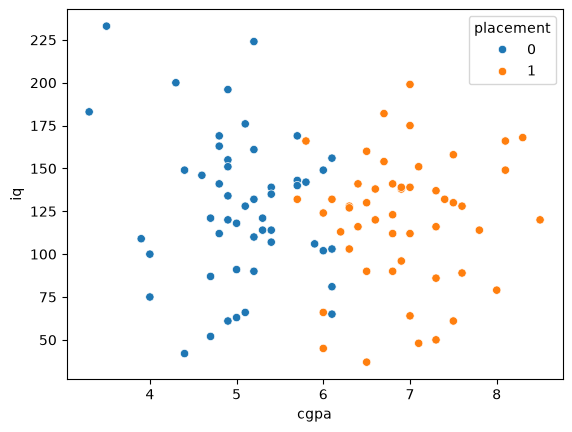

In [12]:
sns.scatterplot(
    x = df['cgpa'] ,
    y = df['iq'] ,
    hue = df['placement']
) 
plt.show()

In [13]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [14]:
X.shape

(100, 2)

In [15]:
y.shape

(100,)

train test split

In [16]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.1)

In [17]:
X_train , X_test , y_train , y_test 

(    cgpa     iq
 89   4.9  151.0
 56   6.1   65.0
 48   6.6  138.0
 37   8.1  149.0
 27   6.0  124.0
 ..   ...    ...
 38   6.5  160.0
 59   4.8  112.0
 53   8.3  168.0
 88   4.4  149.0
 54   6.4  141.0
 
 [90 rows x 2 columns],
     cgpa     iq
 96   4.4   42.0
 66   6.9   96.0
 86   5.1  128.0
 9    5.1   66.0
 23   4.7   87.0
 20   6.6  120.0
 94   4.7   52.0
 80   4.9  196.0
 21   7.1  151.0
 61   7.3  137.0,
 89    0
 56    0
 48    1
 37    1
 27    1
      ..
 38    1
 59    0
 53    1
 88    0
 54    1
 Name: placement, Length: 90, dtype: int64,
 96    0
 66    1
 86    0
 9     0
 23    0
 20    1
 94    0
 80    0
 21    1
 61    1
 Name: placement, dtype: int64)

scaling the values

In [18]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_train

array([[-0.98890657,  0.66364928],
       [ 0.06540646, -1.56289836],
       [ 0.50470355,  0.32707812],
       [ 1.82259484,  0.6118691 ],
       [-0.02245296, -0.03538312],
       [-0.02245296, -1.53700827],
       [ 1.82259484,  1.05200061],
       [ 1.29543832,  0.11995741],
       [ 0.24112529,  0.06817723],
       [-0.72532831,  0.92255016],
       [-0.02245296, -0.60496507],
       [ 0.68042239, -0.91564614],
       [-0.02245296,  0.6118691 ],
       [-1.77964134, -1.30399747],
       [ 1.29543832,  0.8448799 ],
       [ 0.06540646, -1.14865694],
       [ 0.85614123,  0.35296821],
       [ 0.24112529,  0.04228714],
       [-2.39465728,  1.49213212],
       [ 0.59256297,  1.46624203],
       [-1.16462541, -0.11305339],
       [-1.51606309,  1.93226362],
       [ 1.73473542, -1.20043712],
       [-0.98890657,  0.76720963],
       [-0.90104715, -1.61467854],
       [-0.98890657, -1.66645871],
       [-0.6374689 , -0.29428401],
       [ 0.06540646,  0.79309972],
       [-1.86750076,

In [19]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

X_test = scalar.transform(X_test)

model training

In [20]:
clf = LogisticRegression()

In [21]:
clf.fit(X_train , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [25]:
y_pred = clf.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 1])

In [23]:
y_test

96    0
66    1
86    0
9     0
23    0
20    1
94    0
80    0
21    1
61    1
Name: placement, dtype: int64

In [24]:
accuracy_score(y_test ,  y_pred)

1.0

<Axes: >

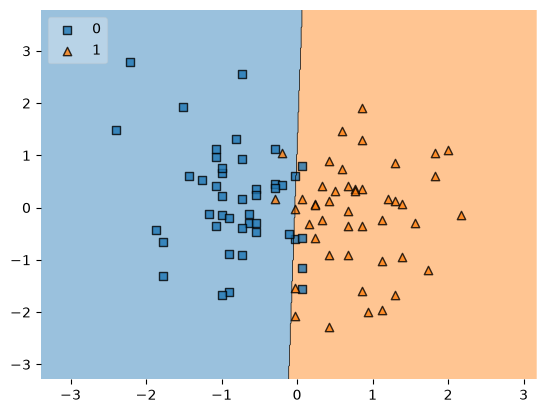

In [27]:
plot_decision_regions(X_train , y_train.values , clf=clf ,legend=2)

In [34]:
with open('toydata.pkl', 'wb') as file:
    pickle.dump(clf, file)